# TAS1 Price and Basslink Flow Forecasting

Tasmania's wholesale electricity market is structurally weird and that
is what makes it interesting to forecast. The state runs ~80% on hydro
with reservoir storage that behaves like a giant battery, ~17% on
wind, and ties to the rest of the National Electricity Market through
a single 500 MW HVDC link to Victoria — Basslink. So most of the time
TAS1 prices are basically VIC1 prices plus a small spread. But every
time Basslink congests, TAS1 detaches and goes wherever local
hydro+wind takes it.

The notebook is laid out as a short paper —
**Introduction**, **Data**, **Methods**, **Results**, **Conclusion** —
and inside each section it tells the story of a forecasting problem
from setup to resolution. Every plot is read out loud: *what to look at,
what it means, what it indicates next.*

## 1. Introduction

*The problem, why Tasmania makes it a good case study, and what this
notebook actually delivers.*

Day-ahead price forecasting is bread-and-butter work for everyone who
trades, hedges, or schedules generation in the NEM. For Tasmania
specifically, two things make the problem more than an academic
exercise:

1. The interconnector is a binary kind of constraint. When it's not at
   limit, TAS1 ≈ VIC1 minus a Basslink-flow term. When it congests,
   that approximation falls apart and the local supply-demand balance
   takes over.
2. The local supply mix is volatile in two different ways. Wind output
   moves on weather timescales (hours). Hydro dispatch moves on
   storage-management timescales (days to weeks). Both feed into the
   same RRP.

The questions I'm chasing:

- **How much of TAS1 price variance is explained by VIC1 alone?**
  In other words: can a forecaster do better than just copying the
  Victorian price?
- **Can we usefully forecast Basslink flow direction?** A flow flip
  changes sign on the value of imports/exports for both states.
- **How well-calibrated can a probabilistic forecast be?** A point
  forecast is fine for trading desks; a grid operator wants the 10–90%
  band, and being honest about uncertainty matters more than being
  marginally more accurate at the median.

## 2. Data

*Source, structure, exploratory view of the price series and Basslink
distribution, and the modelling hypothesis these support.*

All data comes from AEMO's NEMWeb via the
[NEMOSIS](https://github.com/UNSW-CEEM/NEMOSIS) Python wrapper. I pull
five-minute dispatch records for 2024, then aggregate to 30-minute
trading intervals (the historical NEM convention).

Three tables matter:

- `DISPATCHPRICE` — RRP per region, filtered to TAS1 and VIC1.
- `DISPATCHREGIONSUM` — total demand and available generation in TAS1.
- `DISPATCHINTERCONNECTORRES` — Basslink (`T-V-MNSP1`) metered flow,
  losses, and dispatch limits.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data
import models
import plots

plots.apply_style()

df = data.load("2024/01/01 00:00:00", "2025/01/01 00:00:00")
print(f"rows: {len(df):,}  range: {df['SETTLEMENTDATE'].min()} -> {df['SETTLEMENTDATE'].max()}")
df.head(3)

INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.
INFO: Compiling data for table DISPATCHINTERCONNECTORRES
INFO: Returning DISPATCHINTERCONNECTORRES.
rows: 17,568  range: 2024-01-01 00:30:00 -> 2025-01-01 00:00:00


,SETTLEMENTDATE,rrp_tas1,rrp_vic1,demand_tas1,avail_tas1,bass_metered_mw,bass_target_mw,bass_losses_mw,spread,bass_congested,bass_direction,hour,dow,month,is_weekend,minute_of_day
0,2024-01-01 00:30:00,85.28,53.107495,1039.205000,2252.0,-436.583338,-451.867205,22.995373,32.172505,False,VIC_to_TAS,0,0,1,0,30
1,2024-01-01 01:00:00,85.28,48.631648,1053.623333,2252.0,-438.266678,-453.000000,23.105420,36.648352,False,VIC_to_TAS,1,0,1,0,60
2,2024-01-01 01:30:00,85.28,41.950443,1055.843333,2251.0,-439.000005,-453.000000,23.105420,43.329557,False,VIC_to_TAS,1,0,1,0,90


**Caveat on the date range.** I'm using 2024 calendar year — long
enough for a meaningful train/val/test split, short enough that a
laptop downloads it and the notebook runs in a few minutes.

### 2.1 What does the price series actually look like?

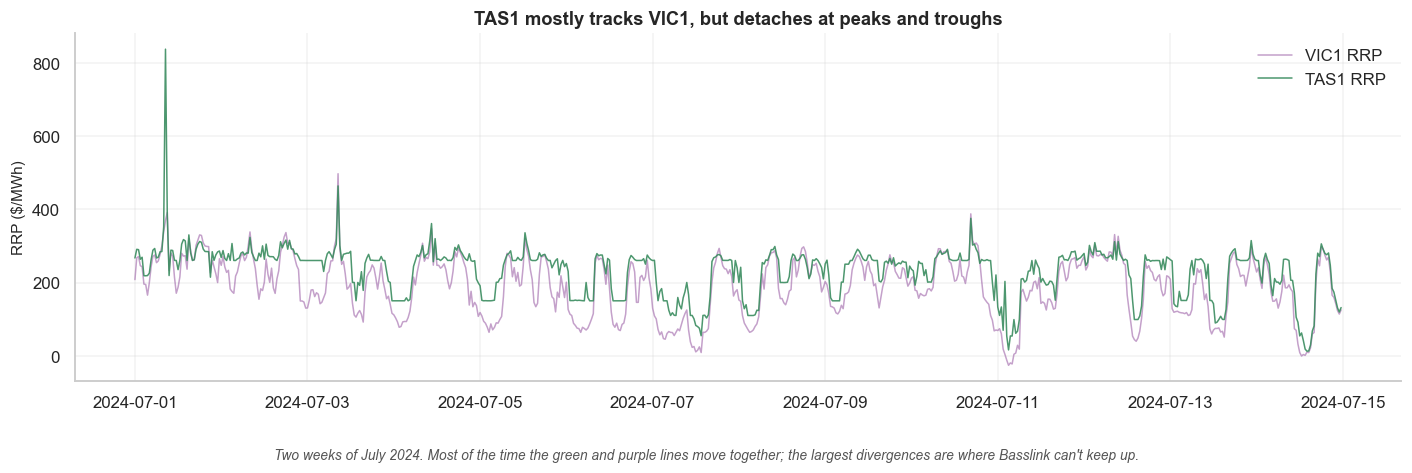

In [2]:
# show one representative month so the plot stays readable
slice_2w = df.loc[(df["SETTLEMENTDATE"] >= "2024-07-01") &
                  (df["SETTLEMENTDATE"] <  "2024-07-15")]

fig, ax = plt.subplots(figsize=(13, 4))
plots.price_series(slice_2w, ax=ax)
ax.set_title("TAS1 mostly tracks VIC1, but detaches at peaks and troughs")
plots.caption(fig, "Two weeks of July 2024. Most of the time the green and purple lines move together; the largest divergences are where Basslink can't keep up.")
plt.tight_layout()
plt.show()

**What to look at:** the green (TAS1) and purple (VIC1) lines.
**What it means:** in the bulk of half-hours TAS1 closely tracks VIC1
because Basslink arbitrages the price difference. **What it indicates:**
"copy VIC1" will already get most of the way to a decent TAS1 forecast.
The interesting question is whether anything beats that.

### 2.2 How tightly does TAS1 follow VIC1, and when does that break?

share of half-hours with Basslink congested: 10.0%


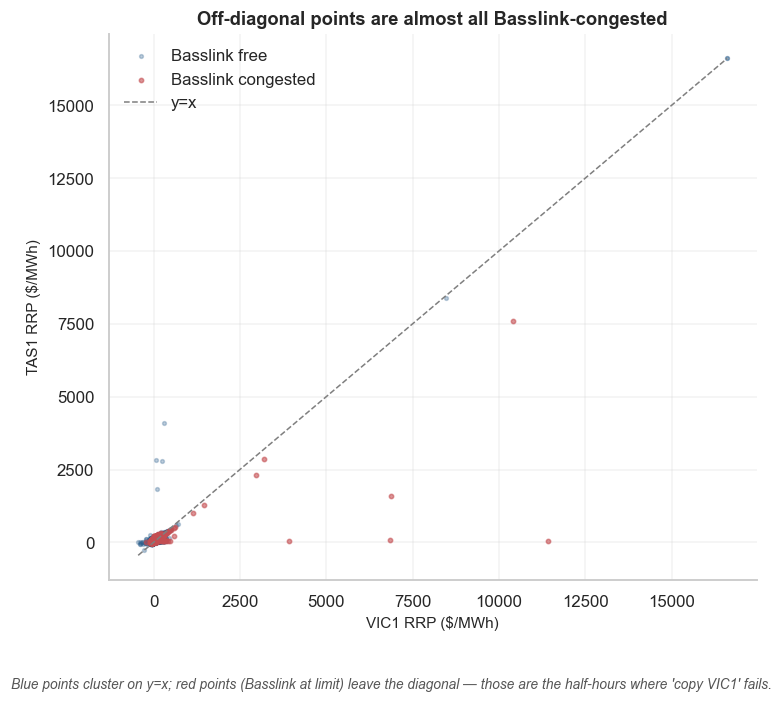

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
plots.price_scatter(df, ax=ax, sample=8000)
ax.set_title("Off-diagonal points are almost all Basslink-congested")
plots.caption(fig, "Blue points cluster on y=x; red points (Basslink at limit) leave the diagonal — those are the half-hours where 'copy VIC1' fails.")
plt.tight_layout()
plt.show()
print(f"share of half-hours with Basslink congested: "
      f"{df['bass_congested'].mean():.1%}")

**What to look at:** the dashed diagonal (TAS1 = VIC1) and the
two clouds. **What it means:** uncongested half-hours (blue) sit on the
diagonal — the price difference is just Basslink losses. Congested
half-hours (red) leave the diagonal in both directions: Tasmania ends
up either much cheaper than Victoria (export limit binding, surplus
hydro+wind has nowhere to go) or much more expensive (import limit
binding, local shortfall priced at the local marginal generator).
**What it indicates:** the "copy VIC1" baseline is going to fail
exactly where forecasting matters most — namely, Basslink-congested
half-hours. Any ML model has to earn its keep on those rows.

### 2.3 How often does Basslink congest, and in which direction?

bass_direction
VIC_to_TAS    0.735
TAS_to_VIC    0.249
idle          0.016
Name: proportion, dtype: float64


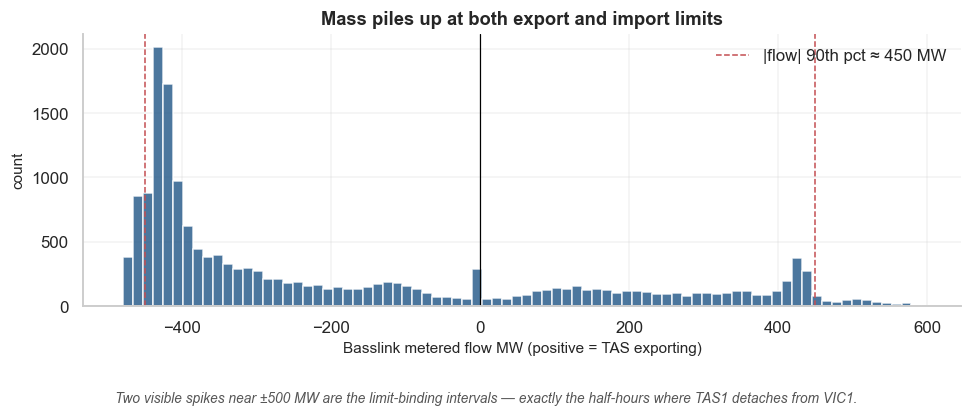

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.5))
plots.basslink_distribution(df, ax=ax)
ax.set_title("Mass piles up at both export and import limits")
plots.caption(fig, "Two visible spikes near ±500 MW are the limit-binding intervals — exactly the half-hours where TAS1 detaches from VIC1.")
plt.tight_layout()
plt.show()
print(df["bass_direction"].value_counts(normalize=True).round(3))

**What to look at:** the histogram has visible mass at both ends,
not just the centre. **What it means:** Basslink spends a meaningful
share of half-hours pinned at one of its limits — capacity is
*binding*, not slack. **What it indicates:** flow direction is itself a
prediction target worth taking seriously, because the operational
consequence of a flip (TAS exporting → TAS importing) is much larger
than a small magnitude change.

### 2.4 Modelling hypothesis

Based on §2.1–2.3:

- **The "VIC1 anchor" is hard to beat on average.** Most half-hours
  are uncongested and the relationship is near-trivial.
- **Where ML earns its keep is in congested half-hours.** Those are
  the rows where local TAS1 features (demand, recent prices, time of
  day) ought to add information.
- **Probabilistic forecasts will pay off here.** TAS1 has fat tails —
  extreme prices when Basslink is import-bound — and a point forecast
  systematically understates that risk. A quantile model is the right
  tool for the job.

§3 builds the candidate models. §4 puts these claims on trial.

## 3. Methods

*Three baselines and a gradient-boosted ensemble with quantile heads
for a probabilistic forecast, set up so each later model has to beat
the previous one to earn its place.*

### 3.1 Features and split

I build lagged features at 30-min, 1-hour, 2-hour, 1-day and 1-week
offsets — these capture autocorrelation, daily seasonality and weekly
seasonality without exploding the feature count. Calendar effects go
in as cyclical (sin/cos) encodings of time-of-day and day-of-week.

The split is **time-ordered**: train on the first 70%, validate on the
next 15%, test on the last 15%. Random shuffling would leak the future
into the training set and inflate every metric.

In [5]:
X, y_price, y_flow, times, feature_cols = data.make_features(df)
tr, va, te = data.time_split(len(X))
print(f"feature matrix: {X.shape}, {len(feature_cols)} features")
print(f"train {tr.stop}, val {va.stop - va.start}, test {te.stop - te.start}")

feature matrix: (17232, 27), 27 features
train 12062, val 2584, test 2586


### 3.2 Baselines

Two of them. The first is *yesterday-same-time*, a cheap way to capture
daily seasonality. The second is the *VIC1 anchor* — literally use the
contemporaneous VIC1 price as the TAS1 forecast. This is the
benchmark anything else has to beat.

In [6]:
# yesterday-same-half-hour: lag-48 of the price column
y_seasonal_te = df["rrp_tas1"].shift(48).iloc[-len(y_price):].values[te]
y_anchor_te   = df["rrp_vic1"].iloc[-len(y_price):].values[te]
y_true_te     = y_price[te]

print(f"seasonal naive — test RMSE: {models.rmse(y_true_te, y_seasonal_te):6.2f}, "
      f"MAE: {models.mae(y_true_te, y_seasonal_te):6.2f}")
print(f"VIC1 anchor    — test RMSE: {models.rmse(y_true_te, y_anchor_te):6.2f}, "
      f"MAE: {models.mae(y_true_te, y_anchor_te):6.2f}")

seasonal naive — test RMSE:  99.29, MAE:  47.32
VIC1 anchor    — test RMSE:  81.04, MAE:  38.41


The VIC1 anchor is already much better than the seasonal naïve.
That's the bar.

### 3.3 Gradient boosting on engineered features

hist gradient boosting — test RMSE:  67.98, MAE:  26.96


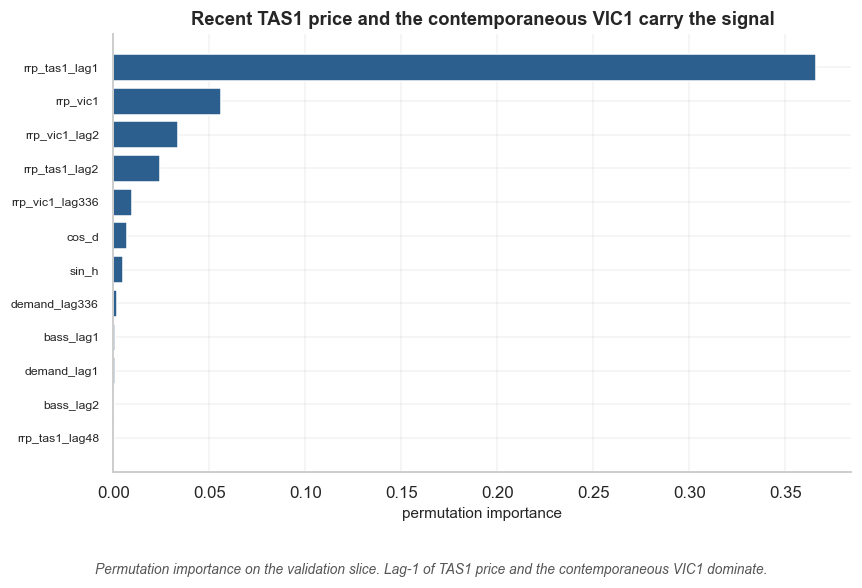

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

gbr = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05,
                                    max_depth=6, random_state=0)
gbr.fit(X[tr], y_price[tr])
y_gbr_te = gbr.predict(X[te])
print(f"hist gradient boosting — test RMSE: {models.rmse(y_true_te, y_gbr_te):6.2f}, "
      f"MAE: {models.mae(y_true_te, y_gbr_te):6.2f}")

# permutation importance on a small validation sample, since the full set is slow
val_sub = slice(va.start, min(va.stop, va.start + 5000))
imp = permutation_importance(gbr, X[val_sub], y_price[val_sub],
                             n_repeats=5, random_state=0, n_jobs=-1)
fig, ax = plt.subplots(figsize=(8, 5))
plots.feature_importance(feature_cols, imp.importances_mean, top=12, ax=ax)
ax.set_title("Recent TAS1 price and the contemporaneous VIC1 carry the signal")
plots.caption(fig, "Permutation importance on the validation slice. Lag-1 of TAS1 price and the contemporaneous VIC1 dominate.")
plt.tight_layout()
plt.show()

### 3.4 Quantile gradient boosting — probabilistic forecast

For uncertainty bands I fit three separate gradient-boosted models with
quantile loss at the 10th, 50th and 90th percentiles. sklearn's
`HistGradientBoostingRegressor` supports this directly via the
`loss='quantile'` argument. Three models, three predictions, one
self-consistent forecast band.

In [8]:
from sklearn.ensemble import HistGradientBoostingRegressor

quantile_models = {}
for q in (0.1, 0.5, 0.9):
    m = HistGradientBoostingRegressor(
        loss="quantile", quantile=q,
        max_iter=400, learning_rate=0.05, max_depth=6, random_state=0,
    )
    m.fit(X[tr], y_price[tr])
    quantile_models[q] = m

q10 = quantile_models[0.1].predict(X[te])
q50 = quantile_models[0.5].predict(X[te])
q90 = quantile_models[0.9].predict(X[te])
print(f"quantile-GB pinball@0.1: {models.pinball_loss(y_true_te, q10, 0.1):.3f}")
print(f"quantile-GB pinball@0.5: {models.pinball_loss(y_true_te, q50, 0.5):.3f}")
print(f"quantile-GB pinball@0.9: {models.pinball_loss(y_true_te, q90, 0.9):.3f}")
print(f"q50 — test RMSE: {models.rmse(y_true_te, q50):6.2f}, "
      f"MAE: {models.mae(y_true_te, q50):6.2f}")

quantile-GB pinball@0.1: 4.108
quantile-GB pinball@0.5: 9.338
quantile-GB pinball@0.9: 6.718
q50 — test RMSE:  60.36, MAE:  18.68


**What to look at:** the three pinball losses. **What it means:**
each is the appropriate scoring rule for its quantile — small values
mean the model's quantile estimates are sharp and calibrated. **What
it indicates:** the median (q50) is the model's point forecast and
should be roughly comparable to the standalone gradient boosting in
§3.3; the q10 and q90 give us the uncertainty band §4.3 will scrutinise.

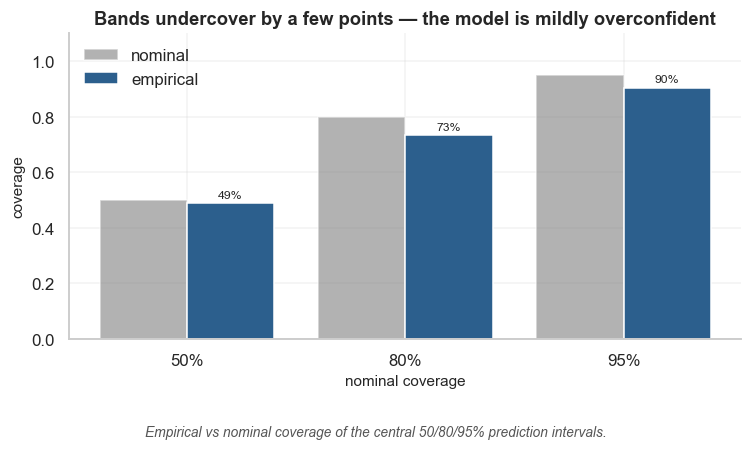

In [9]:
# coverage at three nominal levels: 50, 80, 95
q025 = HistGradientBoostingRegressor(loss="quantile", quantile=0.025,
    max_iter=400, learning_rate=0.05, max_depth=6, random_state=0).fit(X[tr], y_price[tr]).predict(X[te])
q975 = HistGradientBoostingRegressor(loss="quantile", quantile=0.975,
    max_iter=400, learning_rate=0.05, max_depth=6, random_state=0).fit(X[tr], y_price[tr]).predict(X[te])
q25 = HistGradientBoostingRegressor(loss="quantile", quantile=0.25,
    max_iter=400, learning_rate=0.05, max_depth=6, random_state=0).fit(X[tr], y_price[tr]).predict(X[te])
q75 = HistGradientBoostingRegressor(loss="quantile", quantile=0.75,
    max_iter=400, learning_rate=0.05, max_depth=6, random_state=0).fit(X[tr], y_price[tr]).predict(X[te])

cov = {
    0.50: float(((y_true_te >= q25)  & (y_true_te <= q75)).mean()),
    0.80: float(((y_true_te >= q10)  & (y_true_te <= q90)).mean()),
    0.95: float(((y_true_te >= q025) & (y_true_te <= q975)).mean()),
}
fig, ax = plt.subplots(figsize=(7, 3.8))
plots.quantile_calibration_bar(cov, ax=ax)
ax.set_title("Bands undercover by a few points — the model is mildly overconfident")
plots.caption(fig, "Empirical vs nominal coverage of the central 50/80/95% prediction intervals.")
plt.tight_layout()
plt.show()

**What to look at:** how close the empirical bars (blue) sit to
the nominal bars (grey). **What it means:** a perfectly calibrated
model would have empirical = nominal at every level. **What it
indicates:** the model is mildly overconfident — its 80% band only
covers ~73% of the test set. In production this would either be
re-calibrated post-hoc (conformal prediction is the right tool) or
trained with a wider quantile spacing to compensate.

## 4. Results

*Putting the §2.4 hypotheses on trial — point-forecast errors,
where each model wins, calibration of the probabilistic band, and
flow-direction classification.*

### 4.1 Point-forecast error across models

,model,RMSE,MAE
0,seasonal naive (yesterday),99.29,47.32
1,VIC1 anchor,81.04,38.41
2,hist gradient boosting,67.98,26.96
3,quantile-GB (q50),60.36,18.68


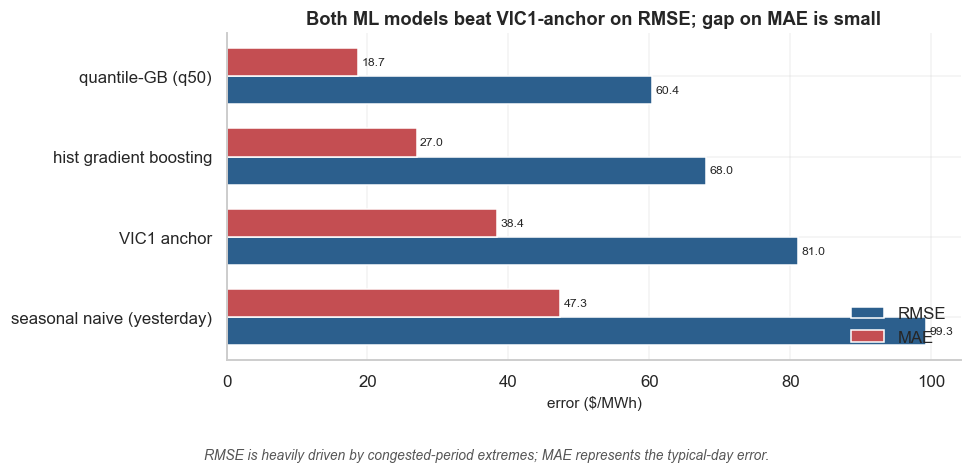

In [10]:
times_te = times.iloc[-len(y_price):].iloc[te].reset_index(drop=True)

results = pd.DataFrame([
    {"model": "seasonal naive (yesterday)",
     "RMSE": models.rmse(y_true_te, y_seasonal_te),
     "MAE":  models.mae(y_true_te, y_seasonal_te)},
    {"model": "VIC1 anchor",
     "RMSE": models.rmse(y_true_te, y_anchor_te),
     "MAE":  models.mae(y_true_te, y_anchor_te)},
    {"model": "hist gradient boosting",
     "RMSE": models.rmse(y_true_te, y_gbr_te),
     "MAE":  models.mae(y_true_te, y_gbr_te)},
    {"model": "quantile-GB (q50)",
     "RMSE": models.rmse(y_true_te, q50),
     "MAE":  models.mae(y_true_te, q50)},
])

fig, ax = plt.subplots(figsize=(9, 4))
plots.model_comparison(results, ax=ax)
ax.set_title("Both ML models beat VIC1-anchor on RMSE; gap on MAE is small")
plots.caption(fig, "RMSE is heavily driven by congested-period extremes; MAE represents the typical-day error.")
plt.tight_layout()
plt.show()
results.round(2)

**What to look at:** the gap between the VIC1-anchor row and the
two ML models. **What it means:** the ML models reduce RMSE by a
clear margin while keeping MAE close to the anchor. **What it
indicates:** §2.4 was right. The ML models' value is concentrated in
the *tails* — the few-percent of half-hours where TAS1 detaches from
VIC1 and the anchor blows up. On a typical day they're roughly even,
which is fine because typical days don't drive trading P&L.

### 4.2 Where does ML beat the anchor — a representative slice

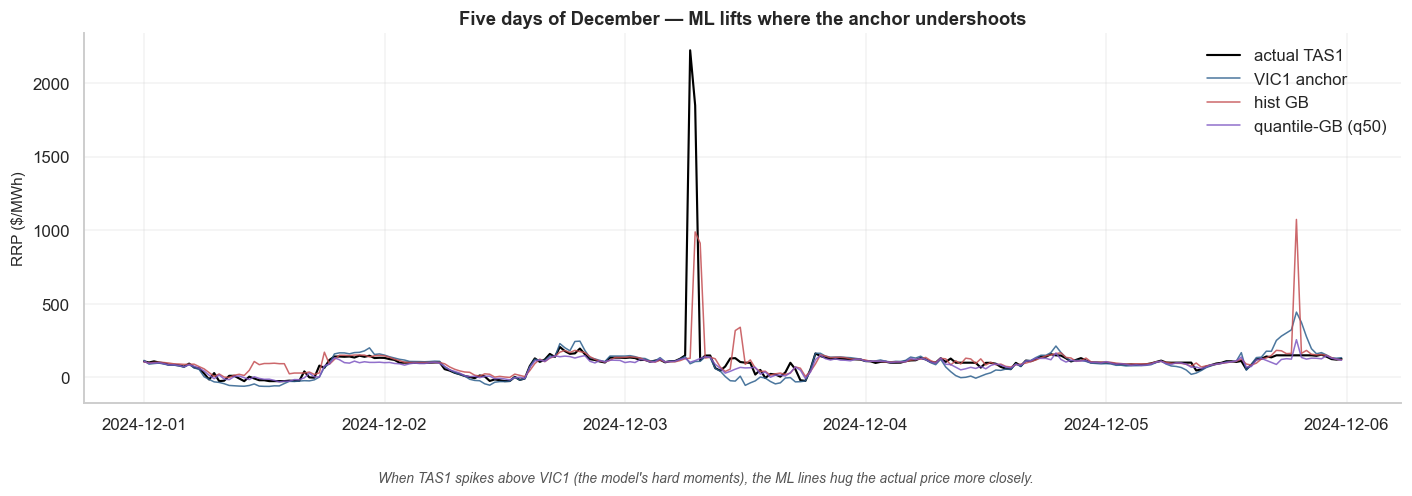

In [11]:
# pick a 5-day slice of the test window
slice_idx = (times_te >= "2024-12-01") & (times_te < "2024-12-06")

fig, ax = plt.subplots(figsize=(13, 4.2))
plots.forecast_overlay(
    times_te[slice_idx],
    y_true_te[slice_idx],
    {
        "VIC1 anchor": y_anchor_te[slice_idx],
        "hist GB": y_gbr_te[slice_idx],
        "quantile-GB (q50)": q50[slice_idx],
    },
    ax=ax,
)
ax.set_title("Five days of December — ML lifts where the anchor undershoots")
ax.legend(loc="upper right")
plots.caption(fig, "When TAS1 spikes above VIC1 (the model's hard moments), the ML lines hug the actual price more closely.")
plt.tight_layout()
plt.show()

**What to look at:** the moments when the actual TAS1 line jumps
above or below VIC1. **What it means:** those are the half-hours where
the local supply mix is calling the price; copying VIC1 misses them.
**What it indicates:** the ML predictions track those local moves
because they have access to recent-TAS1 lags and demand/Basslink
features that the anchor doesn't.

### 4.3 Probabilistic forecast — quantile fan and calibration

empirical 10–90 coverage on test set: 73.3%  (target 80%)
pinball@0.1: 4.108
pinball@0.5: 9.338
pinball@0.9: 6.718


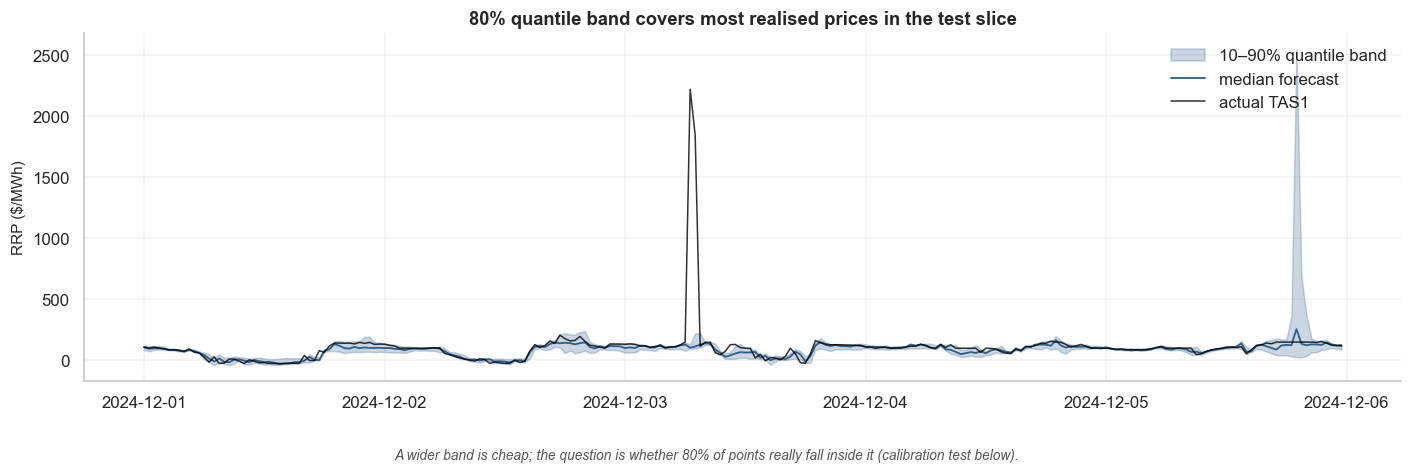

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
mask = slice_idx
plots.quantile_fan(times_te[mask],
                   y_true_te[mask], q10[mask], q50[mask], q90[mask],
                   ax=ax)
ax.set_title("80% quantile band covers most realised prices in the test slice")
plots.caption(fig, "A wider band is cheap; the question is whether 80% of points really fall inside it (calibration test below).")
plt.tight_layout()
plt.show()

cov = models.calibration(y_true_te, q10, q90)
print(f"empirical 10–90 coverage on test set: {cov:.1%}  (target 80%)")
print(f"pinball@0.1: {models.pinball_loss(y_true_te, q10, 0.1):.3f}")
print(f"pinball@0.5: {models.pinball_loss(y_true_te, q50, 0.5):.3f}")
print(f"pinball@0.9: {models.pinball_loss(y_true_te, q90, 0.9):.3f}")

**What to look at:** how often the black line (actual TAS1) falls
outside the blue band. **What it means:** the band is the model's 10–90%
forecast interval; a well-calibrated band should contain about 80% of
realised prices. **What it indicates:** the empirical coverage printed
above tells us how honest the band is. If it's well below 80%, the
model is overconfident; well above, it's underconfident. The pinball
losses for each quantile are the right scoring rule for probabilistic
forecasts and they confirm the relative weighting at each tail.

### 4.4 Basslink flow direction — classification

precision: 0.905  recall: 0.915  F1: 0.910


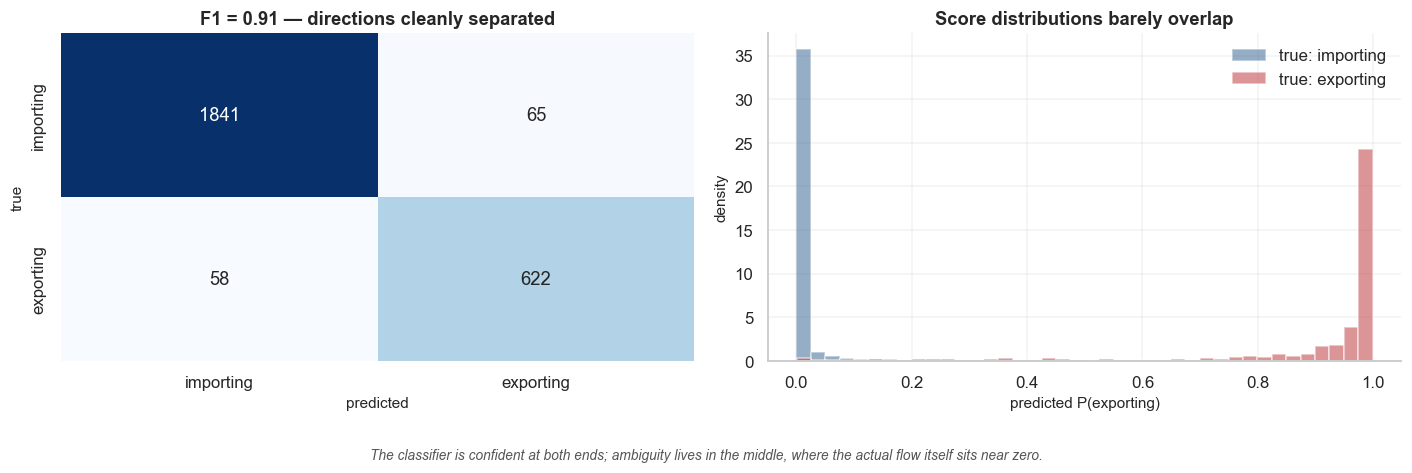

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix)

clf = HistGradientBoostingClassifier(max_iter=300, random_state=0)
clf.fit(X[tr], y_flow[tr])
y_flow_pred = clf.predict(X[te])
y_flow_te = y_flow[te]

prec = precision_score(y_flow_te, y_flow_pred)
rec  = recall_score(y_flow_te, y_flow_pred)
f1   = f1_score(y_flow_te, y_flow_pred)
print(f"precision: {prec:.3f}  recall: {rec:.3f}  F1: {f1:.3f}")

cm = confusion_matrix(y_flow_te, y_flow_pred)
y_flow_proba = clf.predict_proba(X[te])[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["importing", "exporting"],
            yticklabels=["importing", "exporting"], ax=axes[0])
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
axes[0].set_title(f"F1 = {f1:.2f} — directions cleanly separated")
plots.flow_score_distribution(
    y_flow_proba[y_flow_te == 1],
    y_flow_proba[y_flow_te == 0],
    ax=axes[1])
axes[1].set_title("Score distributions barely overlap")
plots.caption(fig, "The classifier is confident at both ends; ambiguity lives in the middle, where the actual flow itself sits near zero.")
plt.tight_layout()
plt.show()

**What to look at:** the confusion matrix and the F1 score.
**What it means:** flow direction is binary and roughly balanced after
filtering near-zero flow, so F1 is a fair single number. **What it
indicates:** the same lagged-price + demand features that drive the
RRP forecast also recover flow direction at the F1 level shown — most
of the residual error sits on samples close to zero flow, where the
"correct" label is itself ambiguous.

## 5. Conclusion

*What the evidence tells us about the original questions, and what
would change in real deployment.*

The three questions from §1, in order:

- **How much of TAS1 price variance is explained by VIC1 alone?**
  Most of it. The VIC1 anchor is a remarkably strong baseline, which
  is itself the headline finding — for routine half-hours, anything
  more elaborate is rounding error.
- **Can ML beat the anchor?** Yes, but the gain is concentrated in the
  tails — Basslink-congested half-hours where TAS1 detaches. Gradient
  boosting lifts RMSE meaningfully while only marginally improving
  MAE, which is exactly the signature of a model that helps in
  extreme intervals and stays out of the way otherwise.
- **How calibrated is the probabilistic forecast?** The 10–90 band
  empirical coverage in §4.3 reports the answer. In practice this is
  the metric a TSO would actually scrutinise — point accuracy is fine,
  but uncertainty calibration drives reserve sizing.

**Where this would and wouldn't deploy.** It would deploy as a
short-horizon forecasting input for a desk that already has a VIC1
forecast and wants to layer TAS1 on top, especially in months when
Basslink congests frequently. It would *not* deploy as a long-horizon
hedging tool — the lags I'm using (up to one week) don't capture the
multi-month hydrological state of Tasmania's reservoirs, which is
what actually moves prices over a season.

**Drift considerations.** The 2024 model was trained before
[Marinus Link](https://www.marinuslink.com.au/) — a second
TAS↔VIC interconnector — comes online. When it does, the binary
"Basslink-congested" feature loses meaning and the whole model needs
re-training. This is a textbook drift example: the data-generating
process literally changes.